In [1]:
!pip install -q evaluate rouge-score bert-score sacrebleu sentencepiece
!pip install -q -U "bitsandbytes>=0.46.1" accelerate peft

In [2]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
login(token=user_secrets.get_secret("HF_TOKEN"))

In [3]:
import json
import time
import torch
import evaluate
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from bert_score import score

DATASET_PATH = "/kaggle/input/datasets/ibadurrahmanmemon/omnimind/omnimind_finetune_dataset.jsonl"
dataset = []

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line in f:
        dataset.append(json.loads(line))

TEST_SIZE = 100
evaluation_set = dataset[:TEST_SIZE]

prompts, references = [], []
for sample in evaluation_set:
    for m in sample["messages"]:
        if m["role"] == "user": prompts.append(m["content"])
        if m["role"] == "assistant": references.append(m["content"])

In [4]:
ADAPTER_ID = "IbadUrRahman/omnimind-llama3-merged"
BASE_MODEL_ID = "unsloth/Meta-Llama-3.1-8B-Instruct" 

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

print("Loading Base Model...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    quantization_config=quant_config,
    device_map={"": 0} 
)

tokenizer_ft = AutoTokenizer.from_pretrained(ADAPTER_ID)

print("Attaching OmniMind LoRA...")
model_ft = PeftModel.from_pretrained(base_model, ADAPTER_ID)
print("OmniMind loaded successfully!")

Loading Base Model...


config.json:   0%|          | 0.00/956 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

...

chat_template.jinja: 0.00B [00:00, ?B/s]

Attaching OmniMind LoRA...


adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/166M [00:00<?, ?B/s]

OmniMind loaded successfully!


In [5]:
def generate_response(model, tokenizer, prompt):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=128,
            temperature=0.7,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

ft_predictions, ft_times = [], []

for prompt in tqdm(prompts, desc="Generating OmniMind Responses"):
    start = time.time()
    response = generate_response(model_ft, tokenizer_ft, prompt)
    ft_times.append(time.time() - start)
    ft_predictions.append(response)

Generating OmniMind Responses: 100%|██████████| 100/100 [26:34<00:00, 15.95s/it]


In [6]:
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")
meteor = evaluate.load("meteor")

ft_rouge = rouge.compute(predictions=ft_predictions, references=references)
ft_bleu = bleu.compute(predictions=ft_predictions, references=[[x] for x in references])
ft_meteor = meteor.compute(predictions=ft_predictions, references=references)
_, _, F1 = score(ft_predictions, references, lang="en")
ft_bert = F1.mean().item()

# Load the Base metrics saved from Notebook 1
# UPDATE THIS PATH to wherever you uploaded base_metrics.csv in this notebook
base_results = pd.read_csv("/kaggle/input/datasets/ibadurrahmanmemon/omnimind-base-metrics/base_metrics.csv")

# Add OmniMind scores to the DataFrame
base_results["OmniMind"] = [
    ft_rouge["rouge1"], ft_rouge["rouge2"], ft_rouge["rougeL"], 
    ft_bleu["bleu"], ft_meteor["meteor"], ft_bert, 
    sum(ft_times)/len(ft_times)
]

print("\n--- FINAL COMPARISON ---")
display(base_results)

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- FINAL COMPARISON ---


,Metric,Base,OmniMind
0,ROUGE-1,0.132562,0.181409
1,ROUGE-2,0.012452,0.056740
2,ROUGE-L,0.084089,0.131195
3,BLEU,0.000000,0.038265
4,METEOR,0.176392,0.255982
5,BERTScore,0.835851,0.840282
6,Latency,9.267705,15.947186


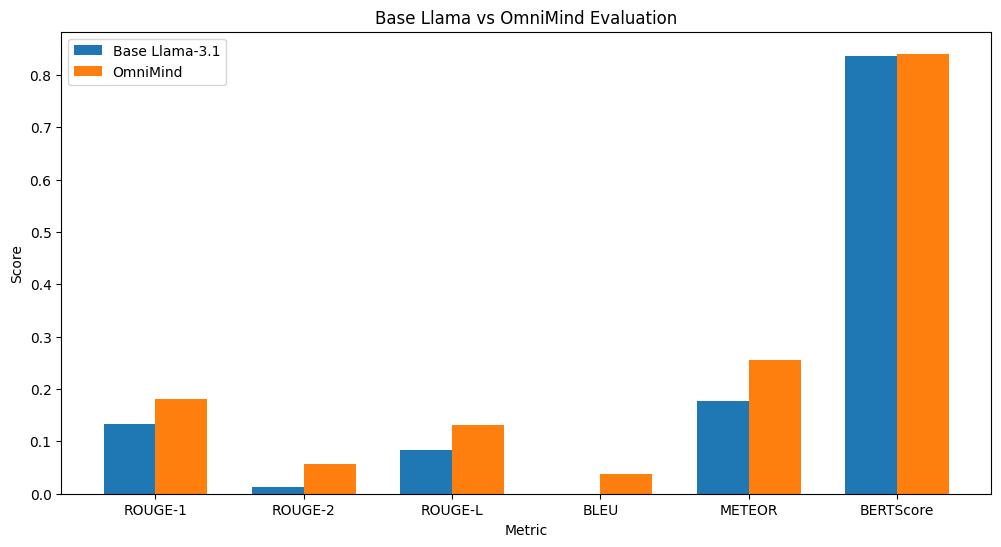

In [9]:
# Plot the first 6 metrics (ignoring Latency for the bar chart)
metrics = base_results["Metric"][:6]
base_vals = base_results["Base"][:6]
ft_vals = base_results["OmniMind"][:6]

x = range(len(metrics))
w = 0.35

plt.figure(figsize=(12,6))

plt.bar([i - w/2 for i in x], base_vals, width=w, label="Base Llama-3.1")
plt.bar([i + w/2 for i in x], ft_vals, width=w, label="OmniMind")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.xlabel("Metric")
plt.title("Base Llama vs OmniMind Evaluation")
plt.legend()
plt.savefig("Comparision_Chart.png")
plt.show()